# 07 — Current players: 2026-27 outlook and Egor Dëmin

Standing at the **end of 2025-26**, apply what the backtest (06) supported (decision D19):

| Question | Method | Backtest evidence (06B) |
|---|---|---|
| Who breaks out in 2026-27? | **Boosted trees**, trained on every season whose outcome is known (≤ 2024-25 → 2025-26) | any breakout 4.2× random (CI 3.3–5.3), best calibrated |
| Who has star potential? | **Current star score** (05), plus the 12-signal logistic probability of a star season within 3 years | 10× random; no trained model beat it |
| "Players like him" | **Nearest comps**: most similar historical rookie seasons, and what happened next | 2.6× random: an explanation, not the main forecast |

These are *probabilities for a rare event*. A 25% breakout chance is high (base rate about 7%) but still means "probably not".

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from unicorn.backtest import boosted_trees, feature_columns, logistic_model
from unicorn.comps import career_after, find_comps
from unicorn.labels import add_future, add_labels, add_star_score
from unicorn.plotting import apply_style, BLUE, ORANGE, INK, INK2, MUTED, FIG_DIR, SERIES, SURFACE
from unicorn.raw import PROJECT_ROOT
from unicorn.unicorn import TRAITS

warnings.filterwarnings("ignore", category=RuntimeWarning)
apply_style()
uni = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "player_season_unicorn.parquet")
BREAKOUTS = ["breakout_any", "breakout_scoring", "breakout_role"]
lab = add_future(add_star_score(add_labels(uni)), BREAKOUTS, horizon=1)
lab = add_future(lab, ["star_season"], horizon=3)
FEATURES = feature_columns(lab)
NOW = 2025                       # 2025-26 is the last completed season
DEMIN = 1642856
young = lab["age"] <= 25
current = lab[young & (lab["season_start"] == NOW)].copy()
print(f"{len(current)} players aged ≤ 25 in 2025-26")

256 players aged ≤ 25 in 2025-26


## Breakout probabilities for 2026-27

In [2]:
for target in [f"{b}_next1" for b in BREAKOUTS]:
    train = lab[young & (lab["season_start"] + 1 <= NOW)]
    current[target] = boosted_trees().fit(train[FEATURES], train[target].astype(int)).predict_proba(current[FEATURES])[:, 1]

SMALL = ["age", "min_per_game_z", "usg_pct_z", "ts_pct_shr_z", "star_score", "usg_pct_z_delta", "min_per_game_z_delta",
         "pct_uast_fgm_z", "ast_pct_z", "fta_rate_z", "draft_pick_filled", "pie_z_delta"]
star_train = lab[young & (lab["star_pctl"].fillna(0) < 0.9) & (lab["season_start"] + 3 <= NOW)]
current["star_within3"] = (logistic_model(C=1.0).fit(star_train[SMALL], star_train["star_season_next3"].astype(int))
                           .predict_proba(current[SMALL])[:, 1])
current["breakout_rank"] = current["breakout_any_next1"].rank(ascending=False).astype(int)

cols = ["player_name", "age", "exp", "min_per_game", "breakout_any_next1", "breakout_scoring_next1", "breakout_role_next1",
        "star_score", "star_within3"]
top = current.nlargest(20, "breakout_any_next1")
display(top[cols].round(2).reset_index(drop=True))

,player_name,age,exp,min_per_game,breakout_any_next1,breakout_scoring_next1,breakout_role_next1,star_score,star_within3
0,Keyonte George,22.23,2.0,33.08,0.64,0.45,0.00,0.28,0.05
1,Anthony Black,22.03,2.0,29.84,0.63,0.42,0.39,0.15,0.03
2,Reed Sheppard,21.61,1.0,26.18,0.57,0.57,0.19,0.24,0.05
3,Matas Buzelis,21.30,1.0,29.20,0.45,0.26,0.20,0.07,0.03
4,Amen Thompson,23.01,2.0,37.38,0.45,0.27,0.06,0.77,0.41
5,Ajay Mitchell,23.61,1.0,25.84,0.41,0.36,0.39,0.54,0.09
6,Jalen Duren,22.21,3.0,28.23,0.34,0.39,0.03,1.07,0.69
7,Bennedict Mathurin,23.62,3.0,30.00,0.33,0.37,0.04,0.07,0.01
8,Brice Sensabaugh,22.26,2.0,23.49,0.33,0.19,0.09,-0.31,0.00
9,Stephon Castle,21.25,1.0,29.97,0.29,0.39,0.03,0.63,0.24


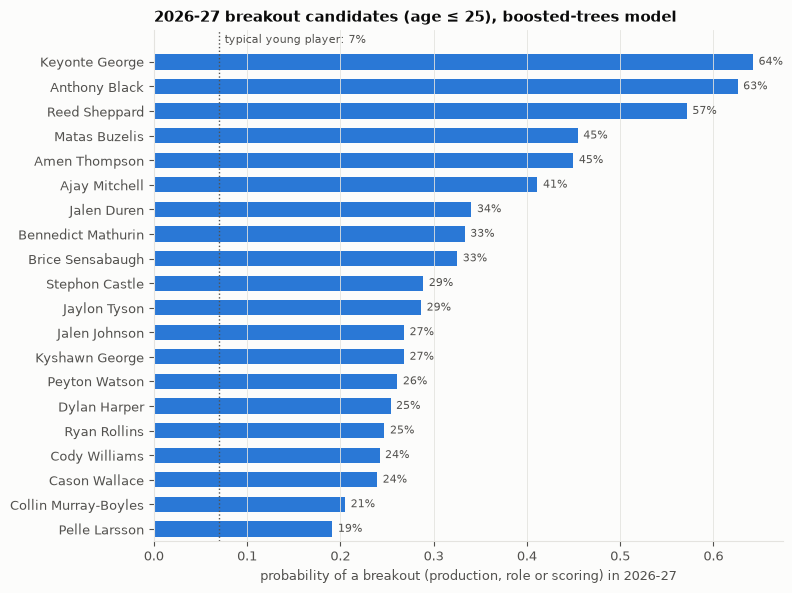

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
y = np.arange(len(top))
ax.barh(y, top["breakout_any_next1"], color=BLUE, height=0.62)
for yi, v in zip(y, top["breakout_any_next1"]):
    ax.annotate(f"{v:.0%}", (v, yi), xytext=(4, 0), textcoords="offset points", va="center", color=INK2, fontsize=8)
base = lab.loc[young & lab["observable_next1"], "breakout_any_next1"].mean()
ax.axvline(base, color=INK2, linestyle=":", linewidth=1)
ax.annotate(f"typical young player: {base:.0%}", (base, -0.9), xytext=(4, 0), textcoords="offset points", color=INK2, fontsize=8, va="center")
ax.set_ylim(len(top) - 0.5, -1.3)
ax.set_yticks(y, top["player_name"]); ax.grid(axis="y", visible=False)
ax.set_xlabel("probability of a breakout (production, role or scoring) in 2026-27")
ax.set_title("2026-27 breakout candidates (age ≤ 25), boosted-trees model", loc="left")
fig.tight_layout(); fig.savefig(FIG_DIR / "07_breakout_candidates_2026_27.png", dpi=150, bbox_inches="tight")

## Egor Dëmin

In [4]:
d = current[current["player_id"] == DEMIN].iloc[0]
rookies = current[(current["exp"] == 0) & (current["min"] >= 500)]
print(f"{d['player_name']}: age {d['age']:.1f}, {d['height_in']:.0f} in, listed {d['position_listed']}, "
      f"{d['gp']:.0f} games, {d['min']:.0f} min ({d['min_per_game']:.1f}/game), {d['ppg']:.1f} ppg")
print(f"breakout in 2026-27: {d['breakout_any_next1']:.1%} (rank {d['breakout_rank']} of {len(current)} young players; "
      f"{(rookies['breakout_any_next1'] > d['breakout_any_next1']).sum() + 1} of {len(rookies)} rookies with ≥ 500 min)")
print(f"  scoring {d['breakout_scoring_next1']:.1%}, role {d['breakout_role_next1']:.1%}")
print(f"star score {d['star_score']:.2f}: rank {(rookies['star_score'] > d['star_score']).sum() + 1} of {len(rookies)} rookies with ≥ 500 min; "
      f"star season within 3 years: {d['star_within3']:.1%}")
print("\nRookies (≥ 500 min) by star score:")
rookies.nlargest(10, "star_score")[["player_name", "age", "min", "star_score", "breakout_any_next1", "star_within3"]].round(2)

Egor Dëmin: age 19.9, 80 in, listed G, 52 games, 1308 min (25.2/game), 10.3 ppg
breakout in 2026-27: 5.3% (rank 89 of 256 young players; 25 of 40 rookies with ≥ 500 min)
  scoring 4.2%, role 7.7%
star score -0.25: rank 14 of 40 rookies with ≥ 500 min; star season within 3 years: 1.8%

Rookies (≥ 500 min) by star score:


,player_name,age,min,star_score,breakout_any_next1,star_within3
7817,Cooper Flagg,19.12,2343.86,0.44,0.05,0.35
7824,Kon Knueppel,20.50,2550.75,0.42,0.16,0.20
7818,Dylan Harper,19.92,1557.96,0.33,0.25,0.18
7819,VJ Edgecombe,20.51,2623.30,0.28,0.15,0.18
7837,Collin Murray-Boyles,20.65,1245.60,0.22,0.21,0.11
7854,Cedric Coward,22.39,1597.95,0.18,0.12,0.04
7861,Dylan Cardwell,24.13,906.54,0.06,0.00,0.02
7587,Ryan Kalkbrenner,24.04,1479.13,0.01,0.02,0.03
7825,Derik Queen,21.10,2023.38,-0.02,0.17,0.04
7857,Javon Small,23.12,829.91,-0.02,0.06,0.01


### Players like him: the most similar historical rookie seasons

Pool: rookie seasons with ≥ 500 minutes from 2011-12 to 2022-23 (so 3 later seasons are observable). Similarity uses the 18 profile features from the backtested comps model: age, size, role, usage, efficiency, passing, ball security, rebounding, defensive activity, shot profile, self-creation and star score.

In [5]:
pool = (lab["exp"] == 0) & (lab["min"] >= 500) & (lab["season_start"] <= NOW - 3)
comps = career_after(lab, find_comps(lab, DEMIN, "2025-26", pool, k=12))
display(comps[["similarity_rank", "player_name", "season", "age", "height_in", "min_per_game", "pts_per36", "ast_pct",
               "fg3a_rate", "distance", "after_any_breakout", "after_star_season", "after_best_star_pctl", "after_best_ppg"]].round(2))

def share_ci(x):
    n, k = len(x), x.sum(); p = k / n; z = 1.96
    centre = (p + z**2 / (2 * n)) / (1 + z**2 / n); half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return f"{p:.0%} (95% CI {centre - half:.0%}–{centre + half:.0%}, n={n})"

c40 = career_after(lab, find_comps(lab, DEMIN, "2025-26", pool, k=40))
all_rookies = career_after(lab, lab[pool].assign(distance=0.0, similarity_rank=0))
print("Within 3 seasons:")
print("  breakout — 40 nearest comps:", share_ci(c40["after_any_breakout"]), "| all rookies:", share_ci(all_rookies["after_any_breakout"]))
print("  star     — 40 nearest comps:", share_ci(c40["after_star_season"]), "| all rookies:", share_ci(all_rookies["after_star_season"]))

,similarity_rank,player_name,season,age,height_in,min_per_game,pts_per36,ast_pct,fg3a_rate,distance,after_any_breakout,after_star_season,after_best_star_pctl,after_best_ppg
5612,1,Kevin Huerter,2018-19,20.43,79.0,27.31,12.78,0.14,0.54,1.93,False,False,0.34,12.21
6148,2,Tyler Herro,2019-20,20.03,77.0,27.42,17.74,0.13,0.47,2.33,True,False,0.76,20.71
4518,3,Mario Hezonja,2015-16,20.93,80.0,17.88,12.18,0.11,0.46,2.46,False,False,0.17,9.63
5118,4,Luke Kennard,2017-18,21.61,77.0,20.04,13.73,0.13,0.42,2.51,False,False,NaN,15.79
4710,5,Jamal Murray,2016-17,19.94,76.0,21.52,16.54,0.14,0.47,2.66,True,False,0.78,18.49
3819,6,Rodney Hood,2014-15,22.28,80.0,21.29,14.65,0.14,0.45,2.72,False,False,0.51,14.70
2471,7,Klay Thompson,2011-12,21.98,79.0,24.36,18.50,0.14,0.37,2.73,True,False,0.93,21.66
6756,8,Vít Krejčí,2021-22,21.62,80.0,23.00,9.76,0.12,0.59,2.89,False,False,NaN,7.23
2835,9,Bradley Beal,2012-13,19.60,77.0,31.15,16.10,0.14,0.34,2.97,False,False,0.60,17.42
2444,10,Brandon Knight,2011-12,20.17,75.0,32.25,14.33,0.20,0.36,2.98,False,False,0.72,17.93


Within 3 seasons:
  breakout — 40 nearest comps: 28% (95% CI 16%–43%, n=40) | all rookies: 21% (95% CI 17%–25%, n=432)
  star     — 40 nearest comps: 2% (95% CI 0%–13%, n=40) | all rookies: 3% (95% CI 2%–5%, n=432)


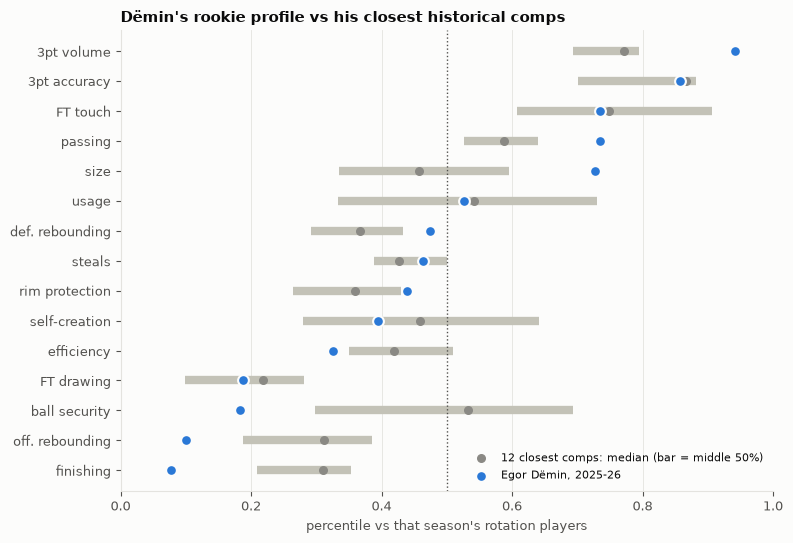

In [6]:
labels = list(TRAITS)
def strengths(rows):
    out = pd.DataFrame({t: rows[f"{c}_pctl"] for t, c in TRAITS.items()})
    out["ball security"] = 1 - out["ball security"]
    return out
demin_p = strengths(lab[(lab["player_id"] == DEMIN) & (lab["season_start"] == NOW)]).iloc[0]
comp_p = strengths(lab.loc[comps.index])
order = demin_p.sort_values().index

fig, ax = plt.subplots(figsize=(8, 5.5))
yy = np.arange(len(order))
ax.hlines(yy, comp_p[order].quantile(0.25), comp_p[order].quantile(0.75), color=MUTED, linewidth=6)
ax.scatter(comp_p[order].median(), yy, color="#8a8984", s=30, zorder=3, label="12 closest comps: median (bar = middle 50%)")
ax.scatter(demin_p[order], yy, color=BLUE, s=60, edgecolor=SURFACE, linewidth=1.5, zorder=4, label="Egor Dëmin, 2025-26")
ax.axvline(0.5, color=INK2, linewidth=1, linestyle=":")
ax.set_yticks(yy, order); ax.set_xlim(0, 1); ax.grid(axis="y", visible=False)
ax.set_xlabel("percentile vs that season's rotation players")
ax.legend(frameon=False, loc="lower right", fontsize=8)
ax.set_title("Dëmin's rookie profile vs his closest historical comps", loc="left")
fig.tight_layout(); fig.savefig(FIG_DIR / "07_demin_profile_vs_comps.png", dpi=150, bbox_inches="tight")

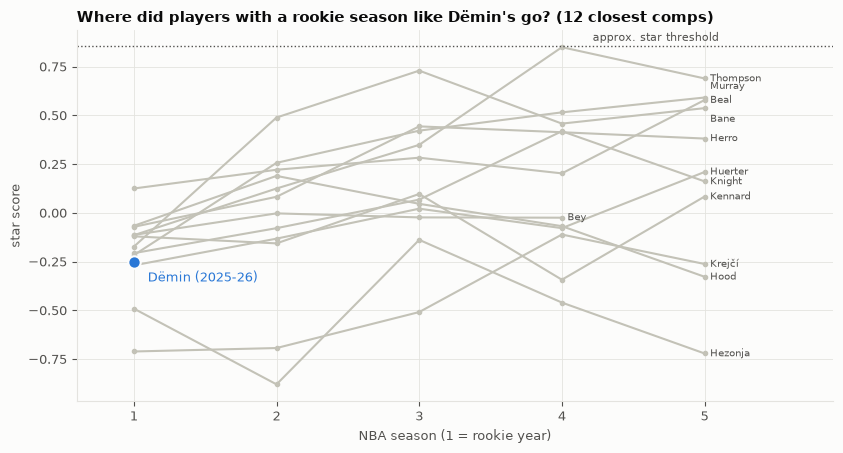

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
for _, c in comps.iterrows():
    path = lab[(lab["player_id"] == c["player_id"]) & (lab["season_start"].between(c["season_start"], c["season_start"] + 4))]
    x = path["season_start"] - c["season_start"] + 1
    ax.plot(x, path["star_score"], color=MUTED, linewidth=1.5, marker="o", markersize=3)
    nudge = {"Jamal Murray": 8, "Bradley Beal": 0, "Desmond Bane": -8}.get(c["player_name"], 0)
    ax.annotate(c["player_name"].split()[-1], (x.iloc[-1], path["star_score"].iloc[-1]), xytext=(4, nudge),
                textcoords="offset points", va="center", fontsize=7, color=INK2)
ax.scatter([1], [d["star_score"]], color=BLUE, s=80, edgecolor=SURFACE, linewidth=1.5, zorder=4)
ax.annotate("Dëmin (2025-26)", (1, d["star_score"]), xytext=(10, -14), textcoords="offset points", ha="left", color=BLUE, fontsize=9)
star_line = lab.loc[lab["star_season"], "star_score"].min()
ax.axhline(star_line, color=INK2, linestyle=":", linewidth=1)
ax.annotate("approx. star threshold", (5.1, star_line), xytext=(0, 4), textcoords="offset points", ha="right", color=INK2, fontsize=8)
ax.set_xticks(range(1, 6)); ax.set_xlim(0.6, 5.9)
ax.set_xlabel("NBA season (1 = rookie year)"); ax.set_ylabel("star score")
ax.set_title("Where did players with a rookie season like Dëmin's go? (12 closest comps)", loc="left")
fig.tight_layout(); fig.savefig(FIG_DIR / "07_demin_comps_trajectories.png", dpi=150, bbox_inches="tight")

In [8]:
out = current[["player_id", "player_name", "season", "age", "exp", "min", "breakout_any_next1", "breakout_scoring_next1",
               "breakout_role_next1", "star_score", "star_within3", "breakout_rank"]]
out.sort_values("breakout_rank").to_csv(PROJECT_ROOT / "outputs" / "tables" / "07_outlook_2026_27.csv", index=False)
comps.to_csv(PROJECT_ROOT / "outputs" / "tables" / "07_demin_comps.csv", index=False)
print("saved outputs/tables/07_outlook_2026_27.csv and 07_demin_comps.csv")

saved outputs/tables/07_outlook_2026_27.csv and 07_demin_comps.csv


## Findings: the 2026-27 outlook

**Breakout candidates (age ≤ 25):** Keyonte George (64%), Anthony Black (63%), Reed Sheppard (57%), Matas Buzelis (45%), Amen Thompson (45%), Ajay Mitchell (41%), vs about 7% for a typical young player. **Caveat:** in the backtest the trees' top probability band averaged about 31%, so predictions above that are extrapolations. Read them as a strong *ranking*, not literal odds.

**Star potential (star within 3 seasons):** Jalen Duren (69%), Amen Thompson (41%), Cooper Flagg (35%), Jalen Johnson (26%), Stephon Castle (24%).

### Egor Dëmin

- **Rookie season (age 19.9, 6-8, listed G):** 52 games, 25.2 min, 10.3 ppg.
- **Breakout chance in 2026-27: 5.3%.** That is about the typical rate: 89th of 256 young players, 25th of 40 rookies with ≥ 500 min. Star score is 14th of those 40 rookies; star season within 3 years: 1.8%.
- **Profile:** elite 3-point volume (94th percentile) with good accuracy (86th), above-average passing (74th) and size (73rd) for a guard. Weak points: finishing at the rim (8th), offensive rebounding (10th), ball security (18th) and overall efficiency (33rd).
- **Closest historical rookie seasons:** Kevin Huerter, Tyler Herro, Mario Hezonja, Luke Kennard, Jamal Murray, Rodney Hood, Klay Thompson, Vít Krejčí, Bradley Beal, Brandon Knight, Saddiq Bey, Desmond Bane: a **shooting-guard/wing archetype**. Compared with them, Dëmin passes more and is bigger, but finishes and protects the ball worse.
- **What happened to them:**
  - 4 of the 12 broke out within 3 seasons (Herro, Murray, Klay, Bane); none had a star season within 3 years (Klay peaked at the 93rd percentile).
  - Across the 40 nearest comps: **28% broke out within 3 seasons (95% CI 16–43%) vs 21% for all rookies; 2% (0–13%) became stars vs 3%.**

**What can honestly be said, as the project set out to earn it:** *based on what was knowable after his rookie season, Dëmin's profile most resembles historical rookie shooters such as Huerter, Herro, Kennard, Murray, Klay and Bane. Players like that broke out somewhat more often than the average rookie, but rarely became stars within three years. His size and passing are what set him apart from that group.*

**Important limitation:** one rookie season says little. The backtest showed the model only caught Shai *after year 2*, once a trajectory existed. Dëmin's 2026-27 changes in usage, minutes, finishing and ball security will matter much more than anything in his rookie numbers.